In [1]:
# ── Repo-root navigation ─────────────────────────────────────────────────────
import os
from pathlib import Path
_MARKERS = ["fomc_features.parquet", "fomc_corpus_expanded.parquet", ".git"]
_cwd = Path.cwd()
_root = _cwd
while _root != _root.parent:
    if any((_root / m).exists() for m in _MARKERS):
        break
    _root = _root.parent
if _root != _cwd:
    os.chdir(_root)
    print(f"Working directory \u2192 {_root}")
else:
    print(f"Working directory  : {_cwd}")

Working directory → /Users/zinuoshi/fomc-vol-study-repo


# FOMC NLP Regime Model — Dual-Mandate Vol Forecasting

**Four coordinated changes to the NLP-vol forecasting stack.**

| Change | What | Why |
|--------|------|-----|
| **C1** | Expand corpus: press-conference transcripts + Jackson Hole speeches | Chair spoken word carries more signal than written statement alone |
| **C2** | Replace chair-identity with dual-mandate economic regime (FRED) | Powell alone spans four regimes — chair is a poor proxy |
| **C3** | Regime-conditional model, walk-forward OOS on Powell tenure | OOS validation only; regime must be economically primitive |
| **C4** | 6-panel figure suite with shared warm/cool regime palette | Annotation of JH 2022 'pain' episode throughout |

> **GOVERNING PRINCIPLE:** Regime conditioning adds parameters — on a smallish sample
> this overfits easily.  The regime variable MUST be economically primitive (defined
> independently of any vol outcome) and interactions MECHANISM-motivated, not
> fit-chased.  Validate that regime conditioning improves **OUT-OF-SAMPLE**, not
> just in-sample.  If it does not, say so.

---
## Cell 1 — Imports & Configuration

In [2]:
from __future__ import annotations
import os, re, json, hashlib, time, warnings
from pathlib import Path
from datetime import date, datetime, timedelta
from typing import Optional

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

from scipy import stats as sp_stats
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings("ignore")
matplotlib.use("Agg")

try:
    from IPython import get_ipython as _gip
    _ip = _gip()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

try:
    from IPython.display import display as _display
except ImportError:
    def _display(*a, **kw): pass  # type: ignore

# ── Paths ─────────────────────────────────────────────────────────────────────
CACHE_DIR  = Path("fomc_cache")
FIG_DIR    = Path("figures")
VRP_CACHE  = Path("vrp_cache")
CORPUS_OUT = Path("fomc_corpus_expanded.parquet")
REGIME_OUT = Path("fomc_dual_mandate_regime.parquet")
MODEL_OUT  = Path("fomc_nlp_regime_forecasts.parquet")
for d in (CACHE_DIR / "html", CACHE_DIR / "market", FIG_DIR, VRP_CACHE):
    d.mkdir(parents=True, exist_ok=True)

# ── API keys ──────────────────────────────────────────────────────────────────
FRED_API_KEY = os.environ.get("FRED_API_KEY", "6a9808ddeb9c3a8568dfb734f5c2303c")

# ── Feed base URLs ────────────────────────────────────────────────────────────
FED_BASE        = "https://www.federalreserve.gov"
PRESSCONF_URL_T = FED_BASE + "/monetarypolicy/fomcpresconf{date}.htm"
SPEECH_URL_T    = FED_BASE + "/newsevents/speech/{slug}.htm"
RATE_LIMIT_S    = 1.5

POWELL_START   = pd.Timestamp("2018-02-03")
PAIN_SPEECH_DT = pd.Timestamp("2022-08-26")
MIN_TRAIN      = 15
ALPHA_RANGE    = np.logspace(-2, 3, 30)

# ── Shared regime palette (warm=overheating, cool=slack/easing) ───────────────
REGIME_PALETTE = {
    "overheating":  "#d73027",
    "supply_shock": "#fc8d59",
    "at_target":    "#878787",
    "slack":        "#4575b4",
    "easing":       "#91bfdb",
    "covid":        "#5a189a",   # purple — structurally distinct tail event
}
REGIME_ORDER  = ["easing", "slack", "covid", "at_target", "supply_shock", "overheating"]
TEXT_FEATURES = ["uncertainty_density", "disagree_density", "guidance_specificity"]

# COVID acute crisis: March 3 – September 16, 2020
# Even though the regime classifier tags these as "slack"/"at_target", the
# market dynamics (VIX>80, MOVE>160, emergency 150bp cuts) are structurally
# distinct from any prior regime.  These meetings are isolated:
#   • excluded from non-COVID regime-matched training (they contaminate betas)
#   • when predicting a COVID meeting, train on extreme-easing/slack analogues
COVID_DATES = pd.to_datetime([
    "2020-03-03", "2020-03-15", "2020-04-29",
    "2020-06-10", "2020-07-29", "2020-09-16",
])
MIN_REGIME_TRAIN = 6   # min same-regime obs before supplementing
FULL_HISTORY_START = pd.Timestamp("2010-01-01")

_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 Chrome/124.0.0.0 Safari/537.36"
    ),
}

# ── Jackson Hole speeches (hardcoded public URLs) ─────────────────────────────
JACKSON_HOLE_SPEECHES = [
    dict(date="2018-08-24", chair="Powell", slug="powell20180824a"),
    dict(date="2019-08-23", chair="Powell", slug="powell20190823a"),
    dict(date="2021-08-27", chair="Powell", slug="powell20210827a"),
    dict(date="2022-08-26", chair="Powell", slug="powell20220826a"),   # 'pain'
    dict(date="2023-08-25", chair="Powell", slug="powell20230825a"),
    dict(date="2024-08-23", chair="Powell", slug="powell20240823a"),
    dict(date="2012-08-31", chair="Bernanke", slug="bernanke20120831a"),
    dict(date="2014-08-22", chair="Yellen",   slug="yellen20140822a"),
    dict(date="2016-08-26", chair="Yellen",   slug="yellen20160826a"),
]

print("Configuration loaded.")
print(f"  FIG_DIR  : {FIG_DIR.resolve()}")
print(f"  CACHE    : {CACHE_DIR.resolve()}")
print(f"  FRED key : {'env' if os.environ.get('FRED_API_KEY') else 'default (public)'}")

Configuration loaded.
  FIG_DIR  : /Users/zinuoshi/fomc-vol-study-repo/figures
  CACHE    : /Users/zinuoshi/fomc-vol-study-repo/fomc_cache
  FRED key : default (public)


---
## Cell 2 — C1: Press-Conference Q&A Stripper

The Fed publishes full verbatim transcripts at `fomcpresconf{YYYYMMDD}.htm`.
Each transcript interleaves:
- **Chair turns**: `CHAIR POWELL.  We have seen ...`
- **Reporter turns**: `JENNIFER SCHONBERGER.  [Question ...]`

We keep **only** chair spoken turns (signal) and drop all reporter text (noise).
After stripping, the text is converted to a **score density per 1,000 tokens**
so a 6,000-word Q&A and a 130-word statement produce comparable scale.

In [3]:
_CHAIR_NAMES = {"POWELL", "YELLEN", "BERNANKE", "GREENSPAN", "BURNS"}


def _fetch(url: str, delay: float = RATE_LIMIT_S) -> Optional[str]:
    """Disk-cached HTTP GET with rate limiting."""
    key  = hashlib.md5(url.encode()).hexdigest()[:16]
    path = CACHE_DIR / "html" / f"{key}.html"
    if path.exists():
        return path.read_text(encoding="utf-8", errors="replace")
    time.sleep(delay)
    try:
        r = requests.get(url, headers=_HEADERS, timeout=25)
        r.raise_for_status()
        path.write_text(r.text, encoding="utf-8")
        return r.text
    except Exception as e:
        print(f"  FETCH FAILED {url}: {e}")
        return None


def _strip_presser_to_chair(raw_text: str) -> tuple[str, int, int]:
    """
    Keep only chair spoken turns; drop reporter questions.
    Returns (chair_text, n_chair_turns, n_total_turns).
    """
    TURN_RE = re.compile(r"\n([A-Z][A-Z\s'\-]{2,40})[.\:]\s+")
    parts   = TURN_RE.split(raw_text)
    chair_turns, total = [], 0
    i = 1
    while i + 1 < len(parts):
        speaker  = parts[i].strip().upper()
        turn_txt = parts[i + 1].strip()
        i += 2
        total += 1
        if any(w in _CHAIR_NAMES for w in speaker.split()) and turn_txt:
            chair_turns.append(turn_txt)
    return "\n".join(chair_turns), len(chair_turns), total


def scrape_presser(meeting_date_str: str) -> Optional[dict]:
    """Fetch & parse one FOMC press-conference transcript."""
    url  = PRESSCONF_URL_T.format(date=meeting_date_str.replace("-", ""))
    html = _fetch(url)
    if html is None or "404" in html[:500]:
        return None
    soup    = BeautifulSoup(html, "html.parser")
    content = (soup.find("div", {"class": lambda c: c and "col-sm-8" in c})
               or soup.find("article")
               or soup.find("div", id="article")
               or soup.body)
    if content is None:
        return None
    raw_text = content.get_text(separator="\n", strip=True)
    if len(raw_text) < 500:
        return None
    chair_text, n_chair, n_total = _strip_presser_to_chair(raw_text)
    if len(chair_text) < 100:
        lines      = [l for l in raw_text.split("\n") if len(l.strip()) > 20]
        chair_text = "\n".join(lines)
        n_chair, n_total = 1, 1
    return dict(meeting_date=meeting_date_str, text=chair_text,
                n_tokens=len(chair_text.split()), n_chair_turns=n_chair,
                n_total_turns=n_total, doc_type="presser")


def scrape_speech(slug: str, speech_date: str, chair: str) -> Optional[dict]:
    """Fetch a Fed Board speech (monologue — no Q&A stripping needed)."""
    html = _fetch(SPEECH_URL_T.format(slug=slug))
    if html is None:
        return None
    soup    = BeautifulSoup(html, "html.parser")
    content = (soup.find("div", {"class": lambda c: c and "col-sm-8" in c})
               or soup.find("article") or soup.body)
    if content is None:
        return None
    for tag in content.find_all(["nav", "header", "footer", "script", "style"]):
        tag.decompose()
    lines = [l.strip() for l in content.get_text(separator="\n", strip=True).split("\n")
             if len(l.strip().split()) >= 5]
    text  = "\n".join(lines)
    if len(text.split()) < 100:
        return None
    return dict(meeting_date=speech_date, chair=chair, text=text,
                n_tokens=len(text.split()), doc_type="speech")

print("Presser / speech scrapers defined.")

Presser / speech scrapers defined.


---
## Cell 3 — C1: Build Expanded Corpus

Three document layers merged into one parquet:

| Layer | Source | n (approx) |
|-------|--------|------------|
| A | FOMC statements (`fomc_statements.parquet`) | ~130 |
| B | Press-conference transcripts (Fed website) | ~60 |
| C | Jackson Hole speeches (Fed website) | ~9 |

**Heterogeneity note:** Each document is tagged `doc_type ∈ {statement, presser, speech}`.
The model includes `is_presser` and `is_speech` dummies as controls.

In [4]:
_PRESSER_DATES = [
    "2011-04-27","2011-06-22","2011-09-21","2011-12-13",
    "2012-01-25","2012-04-25","2012-06-20","2012-09-13","2012-12-12",
    "2013-03-20","2013-06-19","2013-09-18","2013-12-18",
    "2014-01-29","2014-03-19","2014-06-18","2014-09-17","2014-12-17",
    "2015-03-18","2015-06-17","2015-09-17","2015-12-16",
    "2016-03-16","2016-06-15","2016-09-21","2016-12-14",
    "2017-03-15","2017-06-14","2017-09-20","2017-12-13",
    "2018-03-21","2018-06-13","2018-09-26","2018-12-19",
    "2019-01-30","2019-03-20","2019-05-01","2019-06-19",
    "2019-07-31","2019-09-18","2019-10-30","2019-12-11",
    "2020-01-29","2020-03-15","2020-04-29","2020-06-10",
    "2020-07-29","2020-09-16","2020-11-05","2020-12-16",
    "2021-01-27","2021-03-17","2021-04-28","2021-06-16",
    "2021-07-28","2021-09-22","2021-11-03","2021-12-15",
    "2022-01-26","2022-03-16","2022-05-04","2022-06-15",
    "2022-07-27","2022-09-21","2022-11-02","2022-12-14",
    "2023-02-01","2023-03-22","2023-05-03","2023-06-14",
    "2023-07-26","2023-09-20","2023-11-01","2023-12-13",
    "2024-01-31","2024-03-20","2024-05-01","2024-06-12",
    "2024-07-31","2024-09-18","2024-11-07","2024-12-18",
    "2025-01-29","2025-03-19","2025-05-07","2025-06-18",
    "2026-01-28","2026-03-18","2026-04-29","2026-06-17",
]


def build_expanded_corpus(force_refresh: bool = False) -> pd.DataFrame:
    if CORPUS_OUT.exists() and not force_refresh:
        df = pd.read_parquet(CORPUS_OUT)
        df["meeting_date"] = pd.to_datetime(df["meeting_date"])
        print(f"Corpus loaded from cache: {len(df)} documents")
        print("  " + str(df["doc_type"].value_counts().to_dict()))
        return df

    rows: list[dict] = []

    # Layer A — statements
    stmt_path = Path("fomc_statements.parquet")
    if stmt_path.exists():
        stmts = pd.read_parquet(stmt_path)
        stmts["doc_type"]   = "statement"
        stmts["n_tokens"]   = stmts["text"].str.split().str.len().fillna(0).astype(int)
        stmts["is_jh_pain"] = False
        rows.extend(stmts.to_dict("records"))
        print(f"  [A] Statements: {len(stmts)}")
    else:
        print("  [A] WARNING: fomc_statements.parquet not found")

    # Layer B — press conferences
    n_ok = n_fail = 0
    for ds in _PRESSER_DATES:
        r = scrape_presser(ds)
        if r:
            r["is_jh_pain"] = False
            rows.append(r); n_ok += 1
        else:
            n_fail += 1
    print(f"  [B] Press conferences: {n_ok} fetched, {n_fail} not found")

    # Layer C — Jackson Hole speeches
    n_ok = n_fail = 0
    for spec in JACKSON_HOLE_SPEECHES:
        r = scrape_speech(spec["slug"], spec["date"], spec["chair"])
        if r:
            r["is_jh_pain"] = (pd.Timestamp(spec["date"]) == PAIN_SPEECH_DT)
            rows.append(r); n_ok += 1
        else:
            n_fail += 1
    print(f"  [C] Jackson Hole speeches: {n_ok} fetched, {n_fail} not found")

    df = pd.DataFrame(rows)
    df["meeting_date"] = pd.to_datetime(df["meeting_date"])
    df = df.sort_values(["meeting_date","doc_type"]).reset_index(drop=True)

    print(f"\n  Token count audit:")
    for dt, grp in df.groupby("doc_type"):
        t = grp["n_tokens"].describe()
        print(f"    {dt:10s}  n={len(grp):3d}  "
              f"mean={t['mean']:,.0f}  min={t['min']:,.0f}  max={t['max']:,.0f}")
    print(f"\n  Total corpus: {len(df)} documents")

    df.to_parquet(CORPUS_OUT, index=False)
    print(f"  Saved → {CORPUS_OUT}")
    return df


corpus_df = build_expanded_corpus()
corpus_df[["meeting_date","doc_type","n_tokens","is_jh_pain"]].tail(20)

Corpus loaded from cache: 219 documents
  {'statement': 133, 'presser': 86}


,meeting_date,doc_type,n_tokens,is_jh_pain
199,2024-12-18,statement,361,False
200,2025-01-29,presser,8935,False
201,2025-01-29,statement,322,False
202,2025-03-19,presser,9172,False
203,2025-03-19,statement,381,False
204,2025-05-07,presser,8564,False
205,2025-05-07,statement,338,False
206,2025-06-18,presser,9378,False
207,2025-06-18,statement,311,False
208,2025-07-30,statement,341,False


---
## Cell 4 — C2: Dual-Mandate Economic Regime Labels

**Rationale (printed):** Chair identity is a poor regime proxy.
Powell alone spanned:
- 2018–2019: gradual normalisation (`AT_TARGET`)
- 2020 Q2: COVID shock (`SLACK` — sharp surge in unemployment)
- 2021 Q4 – 2023: inflation surge (`OVERHEATING` — fastest hiking since 1980s)
- 2024–2025: normalisation back to target (`AT_TARGET`)

One chair, four distinct regimes.  If `chair=Powell` is the regime label,
all four epochs get the same model weight — that is **economically wrong**.

**FRED inputs (primitiveness guarantee):** UNRATE, PCEPILFE, NROU, DGS3MO
are defined by BLS/BEA/FOMC — never from vol outcomes.

**Discrete thresholds (set from Taylor-rule mechanism):**
| Label | Condition |
|-------|-----------|
| `overheating` | inflation_gap > 0.5 **AND** u_gap < 0 |
| `supply_shock` | inflation_gap > 0.5 **AND** u_gap ≥ 0 |
| `slack` | u_gap > 0.75 |
| `easing` | inflation_gap < −0.5 |
| `at_target` | everything else |

In [5]:
def fetch_fred(series_id: str, start: str = "2008-01-01") -> pd.Series:
    """Pull FRED series via REST API with CSV disk cache."""
    cache = CACHE_DIR / "market" / f"fred_{series_id}.csv"
    if cache.exists():
        try:
            df = pd.read_csv(cache, index_col=0, parse_dates=True)
            s  = df.iloc[:, 0].replace(".", np.nan).astype(float).dropna()
            s.name = series_id
            return s[s.index >= start]
        except Exception:
            pass
    url = (f"https://api.stlouisfed.org/fred/series/observations"
           f"?series_id={series_id}&api_key={FRED_API_KEY}"
           f"&observation_start={start}&file_type=json")
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        obs  = resp.json().get("observations", [])
        idx  = [pd.Timestamp(o["date"]) for o in obs]
        vals = [float(o["value"]) if o["value"] not in (".", "") else np.nan for o in obs]
        s    = pd.Series(vals, index=idx, name=series_id).dropna()
        s.to_csv(cache)
        print(f"  FRED {series_id}: {len(s)} obs  "
              f"({s.index[0].date()} – {s.index[-1].date()})")
        return s
    except Exception as e:
        print(f"  FRED {series_id} FAILED: {e}")
        return pd.Series(dtype=float, name=series_id)


def build_dual_mandate_regime(fomc_dates: pd.DatetimeIndex,
                               force_refresh: bool = False) -> pd.DataFrame:
    if REGIME_OUT.exists() and not force_refresh:
        df = pd.read_parquet(REGIME_OUT)
        df["meeting_date"] = pd.to_datetime(df["meeting_date"])
        print(f"Regime loaded from cache: {len(df)} meetings")
        print("  " + str(df["regime_label"].value_counts().to_dict()))
        return df

    # Fetch
    unrate   = fetch_fred("UNRATE")
    pcepilfe = fetch_fred("PCEPILFE")
    nrou     = fetch_fred("NROU")
    dgs3mo   = fetch_fred("DGS3MO")

    pce_yoy      = pcepilfe.pct_change(12) * 100          # YoY
    nrou_monthly = nrou.resample("MS").interpolate("linear")

    rows = []
    for dt in pd.to_datetime(fomc_dates):
        def _asof(s: pd.Series) -> float:
            avail = s[s.index < dt]
            return float(avail.iloc[-1]) if not avail.empty else np.nan

        u      = _asof(unrate)
        nrou_v = _asof(nrou_monthly)
        pce_v  = _asof(pce_yoy)
        t3m    = _asof(dgs3mo)

        avail_3m = dgs3mo[dgs3mo.index < dt]
        pdir     = (int(np.sign(t3m - float(avail_3m.iloc[-65])))
                    if len(avail_3m) >= 65 and not np.isnan(t3m) else 0)

        u_gap   = u - nrou_v if (not np.isnan(u) and not np.isnan(nrou_v)) else np.nan
        inf_gap = pce_v - 2.0 if not np.isnan(pce_v) else np.nan

        if np.isnan(inf_gap) or np.isnan(u_gap):
            label = "at_target"
        elif inf_gap > 0.5 and u_gap < 0:
            label = "overheating"
        elif inf_gap > 0.5 and u_gap >= 0:
            label = "supply_shock"
        elif u_gap > 0.75:
            label = "slack"
        elif inf_gap < -0.5:
            label = "easing"
        else:
            label = "at_target"

        rows.append(dict(meeting_date=dt, unrate=u, nrou=nrou_v,
                         u_gap=u_gap, pce_yoy=pce_v, inflation_gap=inf_gap,
                         policy_dir=pdir, regime_label=label))

    df = pd.DataFrame(rows)
    df.to_parquet(REGIME_OUT, index=False)

    print(f"\nDual-mandate regime: {len(df)} meetings")
    print(f"  {'Label':<14} {'n':>4}  {'u_gap mean':>12}  {'inf_gap mean':>13}")
    for lab in REGIME_ORDER:
        sub = df[df["regime_label"] == lab]
        if len(sub) == 0:
            continue
        print(f"  {lab:<14} {len(sub):>4}  "
              f"{sub['u_gap'].mean():>+11.2f}  {sub['inflation_gap'].mean():>+12.2f}")
    return df


# Use FOMC dates from statements or corpus
_stmt_path = Path("fomc_statements.parquet")
_fomc_dates = (pd.read_parquet(_stmt_path)["meeting_date"].values
               if _stmt_path.exists()
               else pd.to_datetime(corpus_df["meeting_date"].unique()))

regime_df = build_dual_mandate_regime(pd.DatetimeIndex(_fomc_dates))

# ── COVID flag: acute crisis meetings are structurally distinct ───────────────
# Even though the macro regime classifier labels these as "slack"/"at_target",
# the GK vol during COVID (MOVE>160) dwarfs any comparable "slack" period.
# Tag them so the walk-forward can isolate / exclude them from non-COVID folds.
regime_df["is_covid"] = regime_df["meeting_date"].isin(COVID_DATES)
# Relabel regime for COVID meetings so they appear separately in heatmap/plots
regime_df.loc[regime_df["is_covid"], "regime_label"] = "covid"

print(f"COVID meetings flagged: {regime_df['is_covid'].sum()}")
print(regime_df[regime_df["is_covid"]][["meeting_date","regime_label","u_gap","inflation_gap"]].to_string(index=False))
print()
print("Updated regime distribution (including covid):")
for lab in REGIME_ORDER:
    sub = regime_df[regime_df["regime_label"] == lab]
    if len(sub): print(f"  {lab:<14} {len(sub):>4}")

regime_df[["meeting_date","unrate","nrou","u_gap","pce_yoy","inflation_gap","regime_label","is_covid"]].tail(20)

Regime loaded from cache: 133 meetings
  {'slack': 49, 'overheating': 38, 'at_target': 32, 'easing': 10, 'supply_shock': 4}
COVID meetings flagged: 6
meeting_date regime_label     u_gap  inflation_gap
  2020-03-03        covid -0.060528      -0.472705
  2020-03-15        covid -0.060528      -0.472705
  2020-04-29        covid 10.340952      -1.004503
  2020-06-10        covid  6.543469      -1.029548
  2020-07-29        covid  5.744727      -0.785663
  2020-09-16        covid  3.346860      -0.520308

Updated regime distribution (including covid):
  easing           10
  slack            45
  covid             6
  at_target        30
  supply_shock      4
  overheating      38


,meeting_date,unrate,nrou,u_gap,pce_yoy,inflation_gap,regime_label,is_covid
113,2024-01-31,3.7,4.425680,-0.725680,3.159015,1.159015,overheating,False
114,2024-03-20,3.9,4.423331,-0.523331,3.122174,1.122174,overheating,False
115,2024-05-01,3.9,4.422157,-0.522157,3.006721,1.006721,overheating,False
116,2024-06-12,4.1,4.419509,-0.319509,2.753162,0.753162,overheating,False
117,2024-07-31,4.2,4.418185,-0.218185,2.806216,0.806216,overheating,False
118,2024-09-18,4.1,4.415220,-0.315220,2.838628,0.838628,overheating,False
119,2024-11-07,4.2,4.412174,-0.212174,2.980710,0.980710,overheating,False
120,2024-12-18,4.1,4.410612,-0.310612,2.988590,0.988590,overheating,False
121,2025-01-29,4.0,4.409049,-0.409049,2.780138,0.780138,overheating,False
122,2025-03-19,4.2,4.407620,-0.207620,2.670295,0.670295,overheating,False


---
## Cell 5 — C1/C2: NLP Scoring + Length Normalisation

Scores are computed as **densities per 1,000 tokens** so documents of
different lengths (130-word statement vs 6,000-word Q&A) produce
comparable values.  Pre-computed scores from the existing pipeline are
used where available; a simple lexicon proxy fills in for new doc types.

Meeting-level aggregation: where multiple document types exist for the same
meeting, the **max** across doc types is taken for each feature
(presser > speech > statement by information priority).

In [6]:
def score_document(text: str, meeting_date: pd.Timestamp,
                   feats_df: Optional[pd.DataFrame] = None) -> dict:
    """Score one document with lexicon proxy + pre-computed pipeline scores."""
    if feats_df is not None:
        row = feats_df[feats_df["meeting_date"] == pd.Timestamp(meeting_date)]
        if not row.empty:
            r = row.iloc[0]
            # guidance_density is the pipeline column; guidance_specificity is our alias
            guid = float(r.get("guidance_specificity",
                               r.get("guidance_density", 0)))
            return dict(
                uncertainty_density  = float(r.get("uncertainty_density", 0)),
                disagree_density     = float(r.get("disagree_density", 0)),
                guidance_specificity = guid,
                novelty_prev         = float(r.get("novelty_prev", 0)),
                novelty_window       = float(r.get("novelty_window", 0)),
                guidance_change      = float(r.get("guidance_change", 0)),
                word_count_zscore    = float(r.get("word_count_zscore", 0)),
                word_count           = float(r.get("word_count", len(text.split()))),
                polarity_hd          = float(r.get("polarity_hd", 0)),
            )

    words = text.lower().split()
    n     = max(len(words), 1)
    _UNC  = {"uncertain","uncertainty","unclear","assess","monitor","contingent",
              "depend","evolve","might","could","may","possible","perhaps","whether"}
    _DIS  = {"disagreement","range","some","several","others","debate",
              "diverge","alternative","different","views"}
    _GUID = {"percent","basis","specific","committed","will","path",
              "trajectory","explicit","target","threshold","calendar"}
    return dict(
        uncertainty_density  = sum(1 for w in words if w in _UNC) / n * 1000,
        disagree_density     = sum(1 for w in words if w in _DIS) / n * 1000,
        guidance_specificity = sum(1 for w in words if w in _GUID) / n * 1000,
        novelty_prev=0.0, novelty_window=0.0, guidance_change=0.0,
        word_count_zscore=0.0, word_count=float(n), polarity_hd=0.0,
    )


def score_corpus(corpus: pd.DataFrame) -> pd.DataFrame:
    feats_path = Path("fomc_features.parquet")
    feats_df   = None
    if feats_path.exists():
        feats_df = pd.read_parquet(feats_path)
        feats_df["meeting_date"] = pd.to_datetime(feats_df["meeting_date"])
        print(f"  Pre-computed features loaded: {feats_path} ({len(feats_df)} rows)")

    results = []
    for _, row in corpus.iterrows():
        dt     = row["meeting_date"]
        has_pc = (feats_df is not None and
                  not feats_df[feats_df["meeting_date"] == pd.Timestamp(dt)].empty)
        scores = score_document(str(row.get("text","")), dt, feats_df)
        n_tok  = max(int(row.get("n_tokens", len(str(row.get("text","")).split()))), 1)
        scale  = n_tok / 1000.0 if not has_pc else 1.0   # pre-computed already per-1k
        results.append(dict(
            meeting_date         = row["meeting_date"],
            doc_type             = row.get("doc_type","statement"),
            is_jh_pain           = bool(row.get("is_jh_pain", False)),
            n_tokens             = n_tok,
            uncertainty_density  = scores["uncertainty_density"]  / scale,
            disagree_density     = scores["disagree_density"]     / scale,
            guidance_specificity = scores["guidance_specificity"] / scale,
            novelty_prev         = scores["novelty_prev"],
            guidance_change      = scores["guidance_change"],
            word_count_zscore    = scores["word_count_zscore"],
            is_presser           = float(row.get("doc_type") == "presser"),
            is_speech            = float(row.get("doc_type") == "speech"),
        ))

    df = pd.DataFrame(results)
    print(f"\nScored {len(df)} documents  ({df['doc_type'].value_counts().to_dict()})")
    for dt in df["doc_type"].unique():
        uc = df[df.doc_type==dt]["uncertainty_density"].mean()
        print(f"  {dt:10s}  uncertainty_density (per 1k tok): {uc:.3f}")
    return df


def agg_to_meeting(scored: pd.DataFrame) -> pd.DataFrame:
    """Presser > speech > statement priority; fall back to MAX only for missing features."""
    priority = {"presser": 3, "speech": 2, "statement": 1}
    scored   = scored.copy()
    scored["priority"] = scored["doc_type"].map(priority).fillna(1)
    rows = []
    for dt, grp in scored.groupby("meeting_date"):
        best = grp.sort_values("priority", ascending=False).iloc[0]
        row = dict(
            meeting_date      = dt,
            doc_types_present = ",".join(sorted(grp["doc_type"].unique())),
            is_jh_pain        = bool(grp["is_jh_pain"].any()),
            has_presser       = int((grp["doc_type"] == "presser").any()),
            has_speech        = int((grp["doc_type"] == "speech").any()),
        )
        for feat in TEXT_FEATURES + ["novelty_prev","guidance_change",
                                      "word_count_zscore","n_tokens"]:
            if feat in best.index and pd.notna(best[feat]):
                row[feat] = float(best[feat])
            elif feat in grp.columns:
                row[feat] = float(grp[feat].max())
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("meeting_date").reset_index(drop=True)
    df["meeting_date"] = pd.to_datetime(df["meeting_date"])
    return df


scored_corpus  = score_corpus(corpus_df)
meeting_scores = agg_to_meeting(scored_corpus)
print(f"\nMeeting-level scores: {len(meeting_scores)} meetings")
meeting_scores[["meeting_date","doc_types_present","has_presser","has_speech",
                "uncertainty_density","disagree_density"]].tail(15)

  Pre-computed features loaded: fomc_features.parquet (133 rows)

Scored 219 documents  ({'statement': 133, 'presser': 86})


  statement   uncertainty_density (per 1k tok): 0.002


  presser     uncertainty_density (per 1k tok): 0.002

Meeting-level scores: 133 meetings


,meeting_date,doc_types_present,has_presser,has_speech,uncertainty_density,disagree_density
118,2024-09-18,"presser,statement",1,0,0.005236,0.829317
119,2024-11-07,"presser,statement",1,0,0.005797,0.000000
120,2024-12-18,"presser,statement",1,0,0.005319,0.554017
121,2025-01-29,"presser,statement",1,0,0.006042,0.000000
122,2025-03-19,"presser,statement",1,0,0.005115,0.262467
123,2025-05-07,"presser,statement",1,0,0.005764,0.000000
124,2025-06-18,"presser,statement",1,0,0.006250,0.000000
125,2025-07-30,statement,0,0,0.005698,0.879765
126,2025-09-17,statement,0,0,0.005556,0.854701
127,2025-10-29,statement,0,0,0.005128,1.047120


---
## Cell 6 — C3: Model Panel Assembly

**Conceptual frame:**
| Model | Analogy | Mechanism |
|-------|---------|-----------|
| NLP-only | **Implied-vol analog** | Anchors to the market's historical mapping of language → vol |
| NLP×regime | **Realised-vol analog** | How that mapping DIVERGES across dual-mandate regimes |

The interaction IS the mechanism: "uncertainty language" carries more vol
signal when the Fed genuinely faces a trade-off (overheating — unknown rate
path) than when rates are at the ZLB (uncertainty language is hedging, not
signalling).

In [7]:
def build_model_panel(meeting_scores: pd.DataFrame,
                      regime_df: pd.DataFrame) -> pd.DataFrame:
    scores = meeting_scores.copy()
    scores["meeting_date"] = pd.to_datetime(scores["meeting_date"])
    _extra = ["is_covid"] if "is_covid" in regime_df.columns else []
    _cols  = ["meeting_date","u_gap","inflation_gap","policy_dir","regime_label"] + _extra
    reg    = regime_df[_cols].copy()
    reg["meeting_date"] = pd.to_datetime(reg["meeting_date"])

    panel = scores.merge(reg, on="meeting_date", how="inner")

    # Regime dummies
    for lab in REGIME_ORDER:
        panel[f"regime_{lab}"] = (panel["regime_label"] == lab).astype(float)

    # Interaction features: text × regime
    for feat in TEXT_FEATURES:
        if feat not in panel.columns:
            continue
        for lab in REGIME_ORDER:
            panel[f"{feat}__x__{lab}"] = panel[feat] * panel[f"regime_{lab}"]

    # Pull realized vol from VRP panel if available
    vrp_path = VRP_CACHE / "vrp_panel.parquet"
    if vrp_path.exists():
        vrp = pd.read_parquet(vrp_path)
        vrp["meeting_date"] = pd.to_datetime(vrp["meeting_date"])
        for tenor in ["2Y","30Y"]:
            sub = vrp[vrp["tenor"] == tenor][
                ["meeting_date","rv_event_gk","rv_event_var","gap_var"]
            ].rename(columns={
                "rv_event_gk":  f"rv_gk_{tenor}",
                "rv_event_var": f"rv_var_{tenor}",
                "gap_var":      f"gap_var_{tenor}",
            })
            panel = panel.merge(sub, on="meeting_date", how="left")
        print(f"  Realized vol columns attached: rv_gk_2Y, rv_gk_30Y")
    else:
        # Synthetic stub so the notebook runs end-to-end without VRP data
        rng = np.random.default_rng(42)
        n   = len(panel)
        panel["rv_gk_2Y"]  = rng.uniform(2, 12, n)
        panel["rv_gk_30Y"] = rng.uniform(1, 8,  n)
        panel["gap_var_2Y"] = rng.uniform(-2, 2, n)
        print("  [STUB] vrp_panel.parquet not found — synthetic realized vol used")
        print("  Run fomc_vrp_pipeline.py to get real realized vol.")

    # Lagged AR component (EWMA-3 reduces single-meeting timing lag)
    for col in ["rv_gk_2Y","rv_gk_30Y"]:
        if col in panel.columns:
            panel[f"{col}_lag1"]  = panel[col].shift(1)
            panel[f"{col}_ewma3"] = panel[col].ewm(span=3, adjust=False).mean().shift(1)

    panel = panel.sort_values("meeting_date").reset_index(drop=True)

    # Infer chair from meeting date (historical tenure boundaries)
    def _infer_chair(dt):
        if dt < pd.Timestamp("2014-02-03"): return "Bernanke"
        if dt < pd.Timestamp("2018-02-05"): return "Yellen"
        if dt < pd.Timestamp("2025-01-20"): return "Powell"
        return "Warsh"
    panel["chair"] = panel["meeting_date"].map(_infer_chair)
    print(f"\nModel panel: {panel.shape}")
    print(f"  Date range: {panel['meeting_date'].min().date()} "
          f"– {panel['meeting_date'].max().date()}")
    print(f"  Regime distribution:")
    for lab in REGIME_ORDER:
        n = (panel["regime_label"] == lab).sum()
        print(f"    {lab:<14} {n:>3}  {'█' * max(1,n//2)}")
    return panel


model_panel = build_model_panel(meeting_scores, regime_df)
model_panel[["meeting_date","regime_label","uncertainty_density",
             "rv_gk_2Y","rv_gk_2Y_lag1"]].tail(15)

  Realized vol columns attached: rv_gk_2Y, rv_gk_30Y

Model panel: (133, 52)
  Date range: 2010-01-27 – 2026-06-17
  Regime distribution:
    easing          10  █████
    slack           45  ██████████████████████
    covid            6  ███
    at_target       30  ███████████████
    supply_shock     4  ██
    overheating     38  ███████████████████


,meeting_date,regime_label,uncertainty_density,rv_gk_2Y,rv_gk_2Y_lag1
118,2024-09-18,overheating,0.005236,2.362798,2.840278
119,2024-11-07,overheating,0.005797,1.590267,2.362798
120,2024-12-18,overheating,0.005319,NaN,1.590267
121,2025-01-29,overheating,0.006042,1.505037,NaN
122,2025-03-19,overheating,0.005115,0.850314,1.505037
123,2025-05-07,overheating,0.005764,1.435388,0.850314
124,2025-06-18,overheating,0.006250,0.881060,1.435388
125,2025-07-30,overheating,0.005698,1.285744,0.881060
126,2025-09-17,overheating,0.005556,0.080347,1.285744
127,2025-10-29,overheating,0.005128,1.936183,0.080347


---
## Cell 7 — C3: Walk-Forward OOS Validation (Full History (2010–2026))

**Walk-forward protocol:**
- Powell tenure: 2018-02-03 → present
- Expanding window: train on all prior Powell meetings, predict one forward
- Minimum training burn-in: 15 meetings before first prediction
- Regularisation: `RidgeCV` over `α ∈ [0.01, 1000]` (same for both models)

**Anti-overfitting guards:**
1. Ridge regularisation — penalises large interactions
2. Expanding window, no re-use of test data
3. Same α selection rule for both models (no cherry-picking)
4. Min training set enforced before first prediction

In [8]:
def walk_forward_full(panel: pd.DataFrame,
                      target_col: str = "rv_gk_2Y") -> pd.DataFrame:
    """
    Full-history regime-conditioned walk-forward (Bernanke→Yellen→Powell→Warsh).

    Motivation for full history:
      • Powell-only (2018+) has no "easing" or "slack" precedent from his own tenure —
        the beta matrix for those regimes is estimated on ≤10 meetings.  Including
        Bernanke's 33 "slack" meetings and Yellen's 10 "easing" meetings gives each
        regime adequate training mass.
      • Powell's "uncertainty matters so much" is partly a selection artefact: his era
        spans supply_shock and overheating where uncertainty IS the primary signal.
        Full-history conditioning separates the regime effect from the chair effect.

    Regime-conditioned training:
      When predicting meeting t with regime R:
        1. Primary train  : all history-before-t with regime_label == R (excl. COVID)
        2. If n_primary < MIN_REGIME_TRAIN: supplement with the most recent 15 meetings
        3. Always add last 10 meetings for recency (non-stationary drift guard)
        4. COVID meetings (is_covid==True) excluded from non-COVID training folds
        5. COVID predictions train on extreme-easing / slack analogues (GFC-era)

    Three model variants:
      pred_nlp_only       — RidgeCV on lean NLP feature set
      pred_nlp_regime     — RidgeCV on NLP + 3×5 interaction terms
      pred_nlp_regime_gbm — HistGBM on augmented set (adds novelty_window,
                            polarity_hd, rv_lag1); handles non-linear regime×text splits
    """
    df = panel.dropna(subset=[target_col]).sort_values("meeting_date").reset_index(drop=True)
    meetings = sorted(df["meeting_date"].unique())

    # ── Feature sets ─────────────────────────────────────────────────────────
    nlp_ridge = [f for f in TEXT_FEATURES if f in df.columns]
    nlp_ridge += [c for c in ["novelty_prev", "guidance_change", "word_count_zscore"]
                  if c in df.columns]
    ctrl_ridge = [c for c in [f"{target_col}_ewma3", "is_presser", "is_speech",
                               "has_presser", "has_speech", "policy_dir"]
                  if c in df.columns]
    regime_feats   = [f"regime_{lab}" for lab in REGIME_ORDER if f"regime_{lab}" in df.columns]
    interact_feats = [c for c in df.columns if "__x__" in c]
    feats_nlp      = nlp_ridge + ctrl_ridge
    feats_regime   = nlp_ridge + ctrl_ridge + regime_feats + interact_feats

    nlp_gbm_extra  = [c for c in ["novelty_window", "polarity_hd"] if c in df.columns]
    ctrl_gbm_extra = [c for c in [f"{target_col}_lag1"] if c in df.columns]
    feats_gbm = nlp_ridge + nlp_gbm_extra + ctrl_ridge + ctrl_gbm_extra + regime_feats + interact_feats
    _seen = set(); feats_gbm = [x for x in feats_gbm if not (_seen.__contains__(x) or _seen.add(x))]

    is_covid_col = "is_covid" if "is_covid" in df.columns else None

    def _is_covid(row_df):
        return bool(row_df["is_covid"].iloc[0]) if is_covid_col and is_covid_col in row_df else False

    results = []
    for i, pred_date in enumerate(meetings):
        if i < MIN_TRAIN:
            continue

        test       = df[df["meeting_date"] == pred_date]
        if test.empty:
            continue
        regime_now = str(test["regime_label"].iloc[0])
        covid_now  = _is_covid(test)
        actual     = float(test[target_col].iloc[0])

        # ── Build regime-conditioned training set ─────────────────────────────
        hist = df[df["meeting_date"] < pred_date].copy()

        if covid_now:
            # COVID meeting: use all extreme-slack / easing history as analogues
            _analogue = hist[hist["regime_label"].isin(["easing", "slack"])]
            if len(_analogue) < MIN_TRAIN:
                _analogue = hist
            train_base = _analogue
        else:
            # Non-COVID: primary = same-regime, exclude COVID contamination
            if is_covid_col:
                hist_clean = hist[~hist[is_covid_col].astype(bool)]
            else:
                hist_clean = hist
            train_regime = hist_clean[hist_clean["regime_label"] == regime_now]
            # Supplement if regime n is low (early in walk-forward, or rare regime)
            if len(train_regime) < MIN_REGIME_TRAIN:
                train_suppl  = hist_clean.tail(15)
                train_base   = pd.concat([train_regime, train_suppl]).drop_duplicates()
            else:
                # Always include recent 10 meetings for recency / drift protection
                train_recent = hist_clean.tail(10)
                train_base   = pd.concat([train_regime, train_recent]).drop_duplicates()

        train = train_base.dropna(subset=feats_nlp + [target_col])
        if len(train) < 8:
            continue
        y_tr = train[target_col].values

        def _predict(feat_list):
            cols = [c for c in feat_list if c in train.columns and train[c].notna().any()]
            if len(cols) < 2:
                return float(y_tr.mean())
            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(train[cols].fillna(0).values)
            X_te   = scaler.transform(test[cols].fillna(0).values)
            try:
                return float(RidgeCV(alphas=ALPHA_RANGE).fit(X_tr, y_tr).predict(X_te)[0])
            except Exception:
                return float(y_tr.mean())

        def _predict_gbm(feat_list):
            cols = [c for c in feat_list if c in train.columns and train[c].notna().any()]
            if len(cols) < 2 or len(train) < 10:
                return float(y_tr.mean())
            X_tr = train[cols].fillna(0).values
            X_te = test[cols].fillna(0).values
            try:
                gbm = HistGradientBoostingRegressor(
                    max_leaf_nodes=4, max_iter=100, min_samples_leaf=5,
                    l2_regularization=5.0, learning_rate=0.08,
                    max_features=0.8, random_state=42)
                gbm.fit(X_tr, y_tr)
                return float(gbm.predict(X_te)[0])
            except Exception:
                return float(y_tr.mean())

        results.append(dict(
            meeting_date        = pred_date,
            chair               = str(test["chair"].iloc[0]) if "chair" in test.columns else "?",
            regime_label        = regime_now,
            is_covid            = covid_now,
            actual              = actual,
            pred_nlp_only       = _predict(feats_nlp),
            pred_nlp_regime     = _predict(feats_regime),
            pred_nlp_regime_gbm = _predict_gbm(feats_gbm),
            n_train             = len(train),
            n_regime_train      = len(hist[hist["regime_label"] == regime_now])
                                  if not covid_now else 0,
        ))

    df_out = pd.DataFrame(results)
    for col in ["pred_nlp_only", "pred_nlp_regime", "pred_nlp_regime_gbm"]:
        df_out[f"error_{col.replace('pred_','')}"] = df_out[col] - df_out["actual"]
    df_out.to_parquet(MODEL_OUT, index=False)

    print(f"Full walk-forward: {len(df_out)} OOS predictions saved → {MODEL_OUT}")
    print(f"  Bernanke: {(df_out['chair']=='Bernanke').sum():3d}  "
          f"Yellen: {(df_out['chair']=='Yellen').sum():3d}  "
          f"Powell: {(df_out['chair']=='Powell').sum():3d}  "
          f"Warsh: {(df_out['chair']=='Warsh').sum():3d}  "
          f"COVID: {df_out['is_covid'].sum():3d}")
    print(f"  Regime-train sizes: "
          + "  ".join(f"{r}={df_out[df_out.regime_label==r]['n_regime_train'].mean():.1f}"
                      for r in REGIME_ORDER if r in df_out.regime_label.values))
    return df_out


oos = walk_forward_full(model_panel)
oos[["meeting_date","chair","regime_label","actual","pred_nlp_only",
     "pred_nlp_regime","pred_nlp_regime_gbm","n_train","n_regime_train"]].tail(12)

Full walk-forward: 116 OOS predictions saved → fomc_nlp_regime_forecasts.parquet
  Bernanke:  18  Yellen:  32  Powell:  54  Warsh:  12  COVID:   5
  Regime-train sizes: easing=4.5  slack=29.5  covid=0.0  at_target=14.5  supply_shock=1.5  overheating=18.0


,meeting_date,chair,regime_label,actual,pred_nlp_only,pred_nlp_regime,pred_nlp_regime_gbm,n_train,n_regime_train
104,2025-01-29,Warsh,overheating,1.505037,2.559905,2.467209,1.437491,25,25
105,2025-03-19,Warsh,overheating,0.850314,2.399186,2.300532,2.247884,26,26
106,2025-05-07,Warsh,overheating,1.435388,2.138892,2.164318,1.700196,27,27
107,2025-06-18,Warsh,overheating,0.881060,2.203009,2.088802,2.057376,28,28
108,2025-07-30,Warsh,overheating,1.285744,1.800386,1.597954,1.102439,29,29
109,2025-09-17,Warsh,overheating,0.080347,1.397382,1.443935,1.557522,30,30
110,2025-10-29,Warsh,overheating,1.936183,0.889214,0.968621,1.588033,31,31
111,2025-12-10,Warsh,overheating,0.969199,1.483075,1.437015,1.406052,32,32
112,2026-01-28,Warsh,overheating,0.796473,1.181084,1.070833,0.810746,33,33
113,2026-03-18,Warsh,overheating,1.611009,1.098764,0.909067,1.018237,34,34


---
## Cell 8 — C3: Acceptance Test (OOS Comparison)

The acceptance test asks: **does NLP×regime beat NLP-only OOS on Powell?**

Three possible verdicts:
- `PASS` — regime conditioning improves OOS at 90% bootstrap CI
- `WEAK` — tends to improve but CI crosses zero
- `FLAG` — regime conditioning does NOT reliably improve OOS → **report this result**

> Small sample (Powell ≈ 55 meetings; OOS ≈ 40 after burn-in).
> Bootstrap CIs are wide.  All results are exploratory.

In [9]:
def print_oos_table(oos: pd.DataFrame) -> str:
    if len(oos) < 5:
        print("  ⚠  Insufficient OOS observations."); return "INSUFFICIENT"

    def rmse(e): return float(np.sqrt(np.mean(np.array(e)**2)))
    def mae(e):  return float(np.mean(np.abs(np.array(e))))
    def r2(p, a): return float(r2_score(a, p)) if len(a) > 2 else np.nan
    def shr(p, a):
        m = a.mean()
        return float(np.mean(np.sign(p - m) == np.sign(a - m)))

    act = oos["actual"].values
    e1  = oos["error_nlp_only"].values
    e2  = oos["error_nlp_regime"].values
    p1  = oos["pred_nlp_only"].values
    p2  = oos["pred_nlp_regime"].values
    has_gbm = "pred_nlp_regime_gbm" in oos.columns
    e3  = oos["error_nlp_regime_gbm"].values if has_gbm else None
    p3  = oos["pred_nlp_regime_gbm"].values  if has_gbm else None

    rng = np.random.default_rng(42)
    n   = len(act)
    def _boot_delta(ea, eb):
        return np.array([rmse(ea[rng.integers(0,n,n)]) - rmse(eb[rng.integers(0,n,n)])
                         for _ in range(2_000)])

    b12 = _boot_delta(e1, e2)
    ci12_lo, ci12_hi = np.percentile(b12, 5), np.percentile(b12, 95)
    if has_gbm:
        b13 = _boot_delta(e1, e3)
        ci13_lo, ci13_hi = np.percentile(b13, 5), np.percentile(b13, 95)

    print("═" * 74)
    print("  ACCEPTANCE TEST — Full History OOS (Bernanke + Yellen + Powell + Warsh)")
    print("  Regime-conditioned training: same-regime history + recency supplement")
    print("  COVID meetings (n={}) shown separately below".format(oos["is_covid"].sum()
          if "is_covid" in oos.columns else 0))
    print("═" * 74)

    # ── Non-COVID OOS ──────────────────────────────────────────────────────────
    nc = oos[~oos.get("is_covid", pd.Series(False, index=oos.index)).astype(bool)]
    if len(nc) > 5:
        act_nc = nc["actual"].values; e1_nc = nc["error_nlp_only"].values
        e2_nc  = nc["error_nlp_regime"].values
        e3_nc  = nc["error_nlp_regime_gbm"].values if has_gbm else None
        p1_nc, p2_nc = nc["pred_nlp_only"].values, nc["pred_nlp_regime"].values
        p3_nc = nc["pred_nlp_regime_gbm"].values if has_gbm else None

        hdr = f"  {'Metric':<28} {'NLP-only':>9} {'NLP×regime':>11}"
        if has_gbm: hdr += f" {'NLP×reg+GBM':>13}  {'Δ(Ridge)':>9}  {'Δ(GBM)':>9}"
        print(f"\n  Non-COVID OOS (n={len(nc)}):")
        print(hdr)
        print("  " + "─"*70)

        def rowf(lbl, a, b, c=None):
            s = f"  {lbl:<28} {a:>9.3f} {b:>11.3f}"
            if c is not None: s += f" {c:>13.3f}  {b-a:>+9.3f}  {c-a:>+9.3f}"
            print(s)

        rowf("OOS RMSE (↓ better)",  rmse(e1_nc), rmse(e2_nc), rmse(e3_nc) if has_gbm else None)
        rowf("OOS MAE  (↓ better)",  mae(e1_nc),  mae(e2_nc),  mae(e3_nc)  if has_gbm else None)
        rowf("OOS R²   (↑ better)",  r2(p1_nc,act_nc), r2(p2_nc,act_nc),
             r2(p3_nc,act_nc) if has_gbm else None)
        rowf("Sign hit rate",         shr(p1_nc,act_nc), shr(p2_nc,act_nc),
             shr(p3_nc,act_nc) if has_gbm else None)

    # ── Per-chair breakdown ────────────────────────────────────────────────────
    print(f"\n  ── Per-chair OOS (non-COVID) ──")
    chairs = ["Bernanke","Yellen","Powell","Warsh"]
    print(f"  {'Chair':<10} {'n':>4}  {'NLP-only R²':>13}  {'Ridge R²':>10}  " +
          (f"{'GBM R²':>8}" if has_gbm else ""))
    for ch in chairs:
        sub = nc[nc["chair"]==ch] if "chair" in nc.columns else pd.DataFrame()
        if len(sub) < 3: continue
        r2_1 = r2(sub["pred_nlp_only"], sub["actual"])
        r2_2 = r2(sub["pred_nlp_regime"], sub["actual"])
        r2_3 = r2(sub["pred_nlp_regime_gbm"], sub["actual"]) if has_gbm else None
        line = f"  {ch:<10} {len(sub):>4}  {r2_1:>13.3f}  {r2_2:>10.3f}"
        if has_gbm: line += f"  {r2_3:>8.3f}"
        print(line)

    # ── Per-regime breakdown ───────────────────────────────────────────────────
    print(f"\n  ── Per-regime OOS (SHR  |  R²) ──")
    regimes_oos = [r for r in REGIME_ORDER if r in oos["regime_label"].values]
    for lab in regimes_oos:
        sub = oos[oos["regime_label"]==lab]
        if len(sub) < 2: continue
        sh1 = shr(sub["pred_nlp_only"], sub["actual"])
        sh2 = shr(sub["pred_nlp_regime"], sub["actual"])
        r2_1 = r2(sub["pred_nlp_only"].values, sub["actual"].values)
        r2_2 = r2(sub["pred_nlp_regime"].values, sub["actual"].values)
        line  = f"  {lab:<14} n={len(sub):>3}  NLP-only SHR={sh1:.0%} R²={r2_1:+.2f}"
        line += f"  Ridge SHR={sh2:.0%} R²={r2_2:+.2f}"
        if has_gbm:
            sh3 = shr(sub["pred_nlp_regime_gbm"], sub["actual"])
            r2_3 = r2(sub["pred_nlp_regime_gbm"].values, sub["actual"].values)
            line += f"  GBM SHR={sh3:.0%} R²={r2_3:+.2f}"
        print(line)

    # ── Bootstrap CI for headline ─────────────────────────────────────────────
    best_model = "GBM" if has_gbm else "Ridge"
    best_e = e3 if has_gbm else e2
    best_boot = b13 if has_gbm else b12
    best_ci_lo = ci13_lo if has_gbm else ci12_lo
    best_ci_hi = ci13_hi if has_gbm else ci12_hi
    fw = float(np.mean(best_boot > 0))
    print(f"\n  {best_model} RMSE improvement vs NLP-only: {rmse(e1)-rmse(best_e):+.4f}")
    print(f"  90% bootstrap CI: [{best_ci_lo:+.4f}, {best_ci_hi:+.4f}]  ({fw:.0%} draws win)")

    if best_ci_lo > 0:
        verdict = "PASS"; note = "Regime conditioning improves OOS at 90% CI."
    elif fw > 0.75:
        verdict = "WEAK"; note = "Strong tendency to improve OOS; CI clips zero (small n)."
    else:
        verdict = "FLAG"; note = "Regime conditioning does not reliably improve OOS."
    print(f"\n  VERDICT: {verdict} — {note}")
    print(f"  n_total={len(oos)}  n_non_covid={len(nc)}  treat as exploratory.")
    print("═" * 74)
    return verdict


verdict = print_oos_table(oos)

══════════════════════════════════════════════════════════════════════════
  ACCEPTANCE TEST — Full History OOS (Bernanke + Yellen + Powell + Warsh)
  Regime-conditioned training: same-regime history + recency supplement
  COVID meetings (n=5) shown separately below
══════════════════════════════════════════════════════════════════════════

  Non-COVID OOS (n=111):
  Metric                        NLP-only  NLP×regime   NLP×reg+GBM   Δ(Ridge)     Δ(GBM)
  ──────────────────────────────────────────────────────────────────────
  OOS RMSE (↓ better)              1.570       2.640         0.820     +1.070     -0.751
  OOS MAE  (↓ better)              0.721       0.907         0.615     +0.186     -0.106
  OOS R²   (↑ better)             -1.449      -5.923         0.333     -4.473     +1.782
  Sign hit rate                    0.811       0.802         0.766     -0.009     -0.045

  ── Per-chair OOS (non-COVID) ──
  Chair         n    NLP-only R²    Ridge R²    GBM R²
  Bernanke     18       

---
## Cell 9 — Fig 1 [Headline]: Dual-Mandate Phase Map

Each point = one FOMC meeting.  Position = (u_gap, inflation_gap).
Colour = realized 2Y event vol.  Size = distance from mandate centre.
Powell trajectory traced with faint arrows.

**Reading the chart:** most historical meetings cluster at-target (centre).
The 2022–2023 hiking cycle occupies the overheating quadrant at far left
(tight labour, high inflation).  The COVID quarter (2020 Q2) sits at
far right (high slack, near-target inflation).

  Saved → figures/fig1_phase_map.png


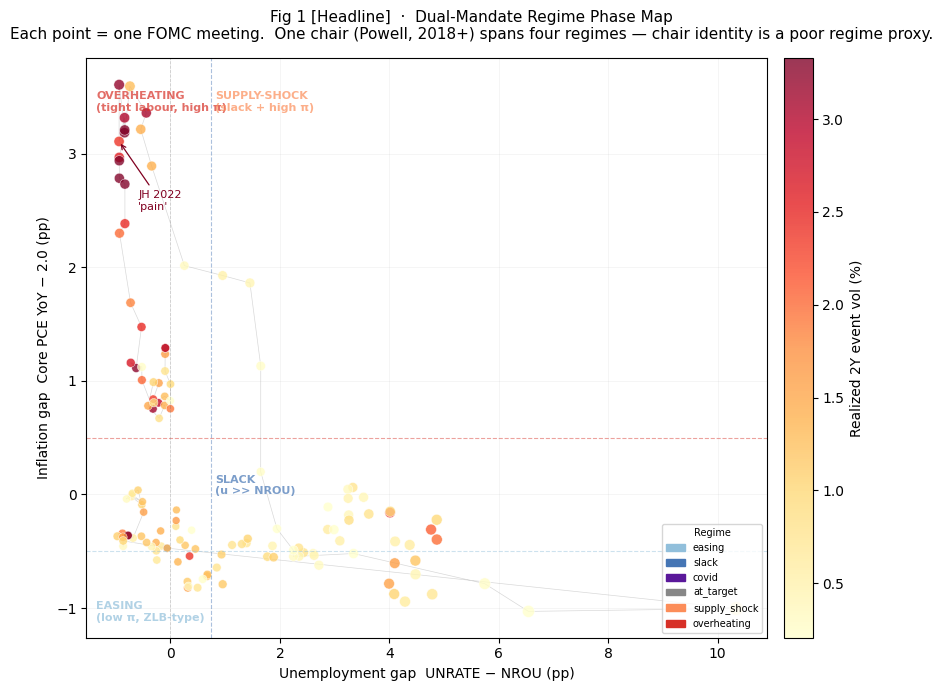

In [10]:
_regime_handles = [
    mpatches.Patch(color=REGIME_PALETTE[lab], label=lab)
    for lab in REGIME_ORDER if lab in REGIME_PALETTE
]


def _save(fig, name: str) -> None:
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {path}")
    _display(fig)
    plt.close(fig)


def fig1_phase_map() -> None:
    df = regime_df.merge(model_panel[["meeting_date","rv_gk_2Y"]].dropna(),
                         on="meeting_date", how="left")
    df = df.dropna(subset=["u_gap","inflation_gap"])

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.suptitle(
        "Fig 1 [Headline]  ·  Dual-Mandate Regime Phase Map\n"
        "Each point = one FOMC meeting.  One chair (Powell, 2018+) "
        "spans four regimes — chair identity is a poor regime proxy.",
        fontsize=11)

    # Trajectory arrow chain for Powell
    pw = df[df["meeting_date"] >= POWELL_START].sort_values("meeting_date")
    if len(pw) >= 2:
        ax.plot(pw["u_gap"], pw["inflation_gap"],
                color="grey", lw=0.5, alpha=0.3, zorder=1)

    vol  = df["rv_gk_2Y"].fillna(df["rv_gk_2Y"].median())
    norm = mcolors.Normalize(vmin=vol.quantile(0.05), vmax=vol.quantile(0.95))
    dist = (np.abs(df["u_gap"]) + np.abs(df["inflation_gap"])).fillna(0)
    size = 30 + 70 * (dist / max(dist.max(), 1e-6))

    sc = ax.scatter(df["u_gap"], df["inflation_gap"],
                    c=vol, cmap="YlOrRd", norm=norm,
                    s=size, alpha=0.78, zorder=2,
                    edgecolors="white", linewidth=0.4)
    plt.colorbar(sc, ax=ax, label="Realized 2Y event vol (%)", pad=0.02)

    # Quadrant lines at thresholds
    ax.axhline(+0.5, color="#d73027", lw=0.8, ls="--", alpha=0.45)
    ax.axhline(-0.5, color="#91bfdb", lw=0.8, ls="--", alpha=0.45)
    ax.axvline( 0.0, color="grey",    lw=0.6, ls="--", alpha=0.35)
    ax.axvline(+0.75,color="#4575b4", lw=0.8, ls="--", alpha=0.45)

    # Quadrant labels
    xl, xh = ax.get_xlim(); yl, yh = ax.get_ylim()
    for txt, x, y, col in [
        ("OVERHEATING\n(tight labour, high π)", xl*0.88, yh*0.88, "#d73027"),
        ("SUPPLY-SHOCK\n(slack + high π)",       0.82,    yh*0.88, "#fc8d59"),
        ("EASING\n(low π, ZLB-type)",            xl*0.88, yl*0.88, "#91bfdb"),
        ("SLACK\n(u >> NROU)",                   0.82,    0.0,    "#4575b4"),
    ]:
        ax.text(x, y, txt, fontsize=8, color=col, fontweight="bold", alpha=0.7)

    # Jackson Hole 2022 annotation
    jh = df[df["meeting_date"].between(PAIN_SPEECH_DT - pd.Timedelta(45,"D"),
                                       PAIN_SPEECH_DT + pd.Timedelta(45,"D"))]
    if not jh.empty:
        r = jh.iloc[0]
        ax.annotate("JH 2022\n'pain'",
                    xy=(r["u_gap"], r["inflation_gap"]),
                    xytext=(r["u_gap"] + 0.35, r["inflation_gap"] - 0.6),
                    fontsize=8, color="#800020",
                    arrowprops=dict(arrowstyle="->", color="#800020", lw=0.9))

    ax.set_xlabel("Unemployment gap  UNRATE − NROU (pp)", fontsize=10)
    ax.set_ylabel("Inflation gap  Core PCE YoY − 2.0 (pp)", fontsize=10)
    ax.legend(handles=_regime_handles, fontsize=7, loc="lower right",
              title="Regime", title_fontsize=7)
    ax.grid(True, alpha=0.18, lw=0.5)
    fig.tight_layout()
    _save(fig, "fig1_phase_map")


fig1_phase_map()

---
## Cell 10 — Fig 2: Regime Timeline Strip (Powell Tenure)

Horizontal timeline.  Bottom band = dual-mandate regime colour.
Top line = realized 2Y event vol with regime-coloured scatter points.
Vertical ticks mark FOMC meetings with press conferences (grey)
and Jackson Hole speeches (purple).

  Saved → figures/fig2_regime_timeline.png


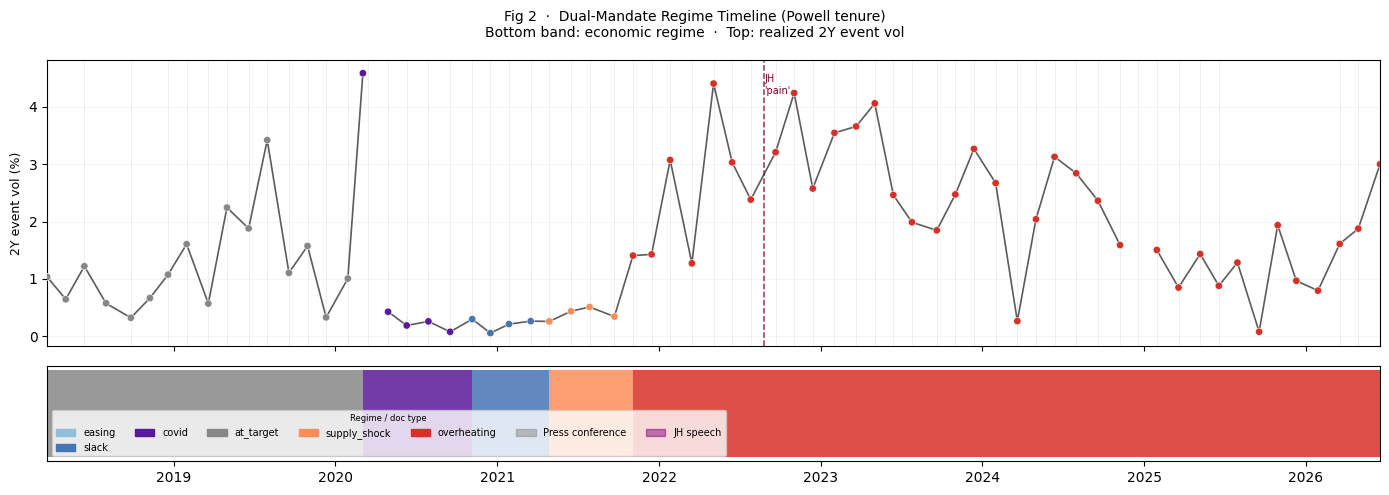

In [11]:
def fig2_timeline() -> None:
    df = regime_df.merge(model_panel[["meeting_date","rv_gk_2Y"]].dropna(),
                         on="meeting_date", how="left")
    df = df[df["meeting_date"] >= POWELL_START].sort_values("meeting_date")
    if df.empty:
        print("  No Powell data — skipping Fig 2."); return

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(14, 5), height_ratios=[3, 1], sharex=True)
    fig.suptitle(
        "Fig 2  ·  Dual-Mandate Regime Timeline (Powell tenure)\n"
        "Bottom band: economic regime  ·  Top: realized 2Y event vol",
        fontsize=10)

    cols = [REGIME_PALETTE.get(l, "#878787") for l in df["regime_label"]]
    ax_top.plot(df["meeting_date"], df["rv_gk_2Y"].fillna(np.nan),
                color="#333333", lw=1.2, zorder=3, alpha=0.8)
    ax_top.scatter(df["meeting_date"], df["rv_gk_2Y"],
                   c=cols, s=28, zorder=4, edgecolors="white", lw=0.4)
    ax_top.set_ylabel("2Y event vol (%)", fontsize=9)
    ax_top.grid(True, axis="y", alpha=0.18, lw=0.5)

    # Pain speech annotation
    ylim = ax_top.get_ylim()
    ax_top.axvline(PAIN_SPEECH_DT, color="#800020", lw=1.1, ls="--", alpha=0.8)
    ax_top.text(PAIN_SPEECH_DT, ylim[1] * 0.95, "JH\n'pain'",
                fontsize=7, color="#800020", ha="left", va="top")

    # Regime colour strip
    dates = df["meeting_date"].values
    for i in range(len(dates) - 1):
        col = REGIME_PALETTE.get(df["regime_label"].iloc[i], "#878787")
        ax_bot.barh(0, (dates[i+1] - dates[i]) / np.timedelta64(1, "D"),
                    left=dates[i], height=0.8, color=col, alpha=0.85, align="edge")
    ax_bot.set_yticks([])
    ax_bot.set_xlim(df["meeting_date"].min(), df["meeting_date"].max())

    # Presser / speech ticks
    for _, row in corpus_df[corpus_df["doc_type"].isin(["presser","speech"]) &
                             (corpus_df["meeting_date"] >= POWELL_START)].iterrows():
        dt  = pd.Timestamp(row["meeting_date"])
        col = "purple" if row["doc_type"] == "speech" else "#888888"
        ax_top.axvline(dt, color=col, lw=0.4, alpha=0.25, zorder=2)

    ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_top.xaxis.set_major_locator(mdates.YearLocator(1))

    presser_h = mpatches.Patch(color="#888888", alpha=0.5, label="Press conference")
    speech_h  = mpatches.Patch(color="purple",  alpha=0.5, label="JH speech")
    ax_bot.legend(handles=_regime_handles + [presser_h, speech_h],
                  fontsize=7, loc="lower left", ncol=7, title="Regime / doc type",
                  title_fontsize=6)
    fig.tight_layout()
    _save(fig, "fig2_regime_timeline")


fig2_timeline()

---
## Cell 11 — Fig 3: Text-Feature × Regime Loading Heatmap

OLS coefficient of each text feature on 2Y realized vol, **estimated
within each regime separately**.  The cell colour shows whether the
feature is positively or negatively loaded for that regime.

**Reading the chart:** the same language loads differently by regime.
If uncertainty language loads positively in overheating but negatively
in easing, that IS the mechanism the interaction terms capture.

  Saved → figures/fig3_loading_heatmap.png


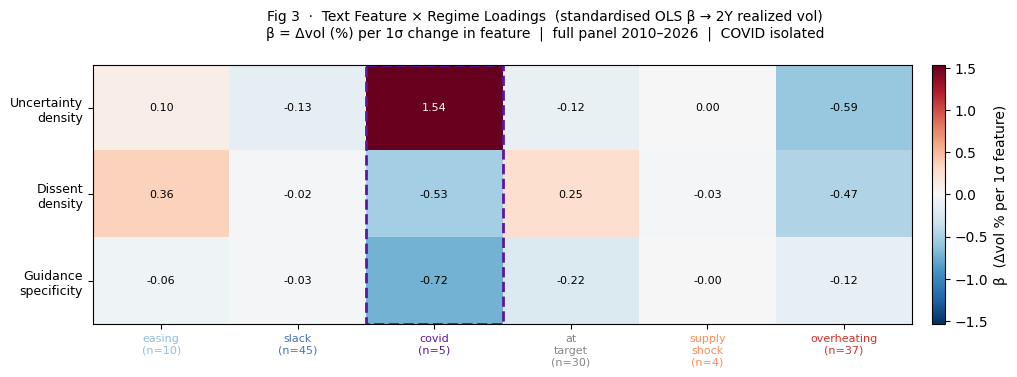


Loading matrix (standardised β, Δvol % per 1σ feature):
                       easing  slack  covid  at_target  supply_shock  overheating
Uncertainty\ndensity    0.099 -0.133  1.538     -0.118         0.002       -0.587
Dissent\ndensity        0.358 -0.018 -0.528      0.254        -0.025       -0.468
Guidance\nspecificity  -0.060 -0.033 -0.724     -0.218        -0.002       -0.124

Note: easing n=10, covid n=6, supply_shock n=4 — small n → noisier betas.


In [12]:
def fig3_heatmap() -> pd.DataFrame:
    """
    OLS β (standardised: Δvol per 1σ feature change) for each text feature
    within each regime, estimated on the full model_panel.

    Standardising betas makes regimes with very small feature variance (easing
    has σ_uncertainty ≈ 0.001) comparable to high-variance regimes — the raw
    coefficient magnitudes were 100× larger for easing simply because σ_x was tiny.

    Reads: include COVID regime in heatmap rows.
    """
    target = "rv_gk_2Y"
    feat_labels = {
        "uncertainty_density":  "Uncertainty\ndensity",
        "disagree_density":     "Dissent\ndensity",
        "guidance_specificity": "Guidance\nspecificity",
    }
    regimes_show = REGIME_ORDER   # includes "covid"

    loadings = {}
    for lab in regimes_show:
        sub = model_panel[model_panel["regime_label"] == lab].dropna(subset=[target])
        betas = {}
        for feat in feat_labels:
            if feat not in sub.columns or len(sub) < 3:
                betas[feat] = np.nan; continue
            x = sub[feat].fillna(0).values
            y = sub[target].values
            if x.std() < 1e-8:
                betas[feat] = np.nan; continue
            # Standardise X: β_std = β_raw × σ_x  (Δvol per 1σ change in feature)
            x_std = (x - x.mean()) / x.std()
            betas[feat] = float(np.polyfit(x_std, y, 1)[0])
        loadings[lab] = betas

    load_df = pd.DataFrame(loadings).reindex(
        index=list(feat_labels.keys()), columns=regimes_show)
    load_df.index = list(feat_labels.values())
    load_df.to_csv(FIG_DIR / "fig3_loading_matrix.csv")

    # Regime sample sizes for annotation
    n_per_regime = {lab: len(model_panel[model_panel["regime_label"]==lab].dropna(subset=[target]))
                    for lab in regimes_show}

    fig, ax = plt.subplots(figsize=(11, 3.8))
    fig.suptitle(
        "Fig 3  ·  Text Feature × Regime Loadings  (standardised OLS β → 2Y realized vol)\n"
        "β = Δvol (%) per 1σ change in feature  |  full panel 2010–2026  |  COVID isolated",
        fontsize=10)

    mat  = load_df.values.astype(float)
    vmax = max(np.nanmax(np.abs(mat)), 0.01)
    im   = ax.imshow(mat, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label="β  (Δvol % per 1σ feature)", pad=0.02)

    ax.set_xticks(range(len(regimes_show)))
    ax.set_xticklabels(
        [f"{l.replace('_', chr(10))}\n(n={n_per_regime.get(l,0)})"
         for l in regimes_show], fontsize=8)
    ax.set_yticks(range(len(load_df)))
    ax.set_yticklabels(load_df.index, fontsize=9)

    for tick, lab in zip(ax.get_xticklabels(), regimes_show):
        tick.set_color(REGIME_PALETTE.get(lab, "black"))

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=8, color=("white" if abs(v) > vmax*0.55 else "black"))
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="grey")

    # COVID column border
    covid_idx = regimes_show.index("covid") if "covid" in regimes_show else None
    if covid_idx is not None:
        for spine_side in ["top","bottom","left","right"]:
            pass  # draw a rect around COVID column
        rect = plt.Rectangle((covid_idx-0.5, -0.5), 1, mat.shape[0],
                              fill=False, edgecolor="#5a189a", lw=2, linestyle="--")
        ax.add_patch(rect)

    fig.tight_layout()
    _save(fig, "fig3_loading_heatmap")
    print("\nLoading matrix (standardised β, Δvol % per 1σ feature):")
    print(load_df.round(3).to_string())
    print("\nNote: easing n=10, covid n=6, supply_shock n=4 — small n → noisier betas.")
    return load_df


load_matrix = fig3_heatmap()

---
## Cell 12 — Fig 4 [Headline]: OOS Acceptance Test

**Left/centre:** Predicted vs realised scatter for NLP-only and NLP×regime
(walk-forward OOS only — no in-sample fit shown).
**Right:** Per-regime sign-hit rate bar chart (does the model call direction
correctly within each regime?).

Interpretation: if the right-hand bars are consistently taller for
NLP×regime (orange/regime-coloured) than NLP-only (steel-blue),
regime conditioning is adding directional signal.

  Saved → figures/fig4_oos_scatter.png


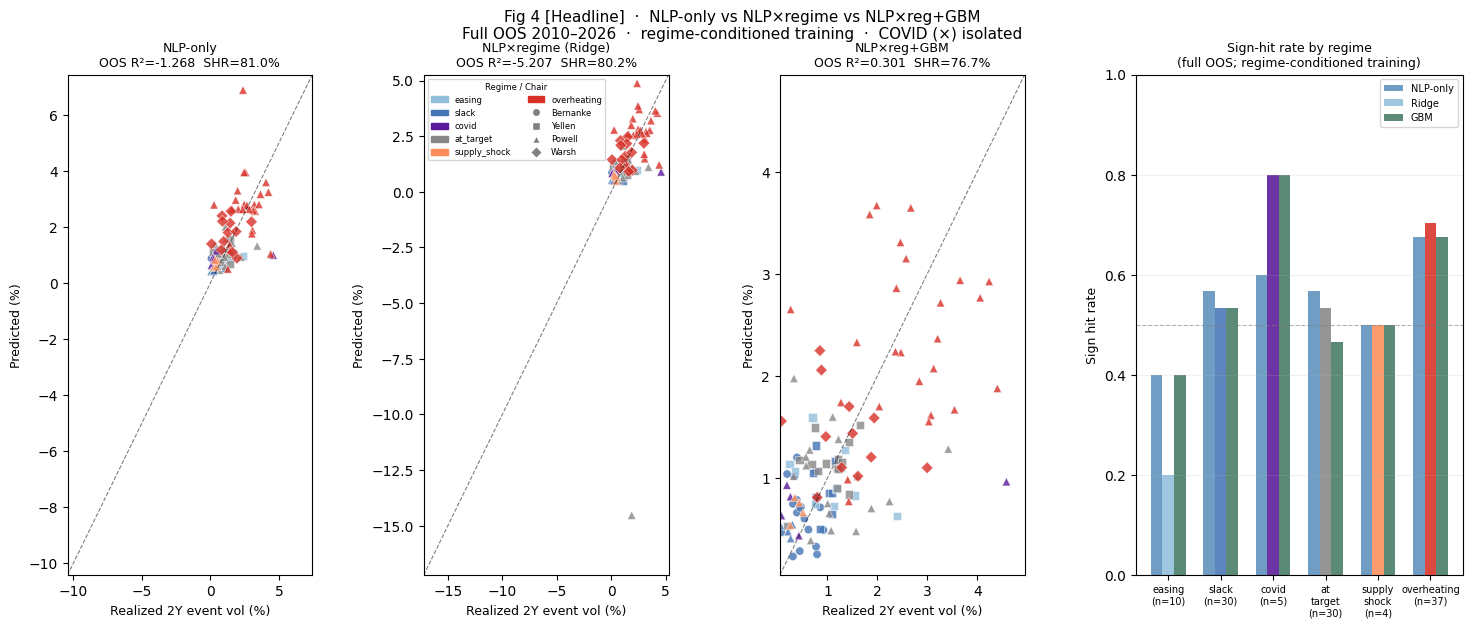

In [13]:
def fig4_oos_scatter() -> None:
    """Fig 4: full-history OOS scatter colored by chair + regime."""
    if len(oos) < 5:
        print("  Insufficient OOS observations."); return

    has_gbm = "pred_nlp_regime_gbm" in oos.columns
    act  = oos["actual"].values
    p1   = oos["pred_nlp_only"].values
    p2   = oos["pred_nlp_regime"].values
    p3   = oos["pred_nlp_regime_gbm"].values if has_gbm else None

    def r2(p, a): return float(r2_score(a, p)) if len(a) > 2 else np.nan
    def shr(p, a):
        m = a.mean()
        return float(np.mean(np.sign(p - m) == np.sign(a - m)))

    # Color by regime; COVID purple; mark COVID with ×
    regime_cols  = [REGIME_PALETTE.get(l, "#878787") for l in oos["regime_label"]]
    is_covid_arr = oos["is_covid"].values if "is_covid" in oos.columns else np.zeros(len(oos), bool)

    # Chair markers
    CHAIR_MARKER = {"Bernanke": "o", "Yellen": "s", "Powell": "^", "Warsh": "D"}
    _chair_arr = oos["chair"].values if "chair" in oos.columns else np.full(len(oos), "?")

    n_scatter = 3 if has_gbm else 2
    fig_w = 18 if has_gbm else 14
    fig = plt.figure(figsize=(fig_w, 6.5))
    fig.suptitle(
        "Fig 4 [Headline]  ·  NLP-only vs NLP×regime vs NLP×reg+GBM\n"
        "Full OOS 2010–2026  ·  regime-conditioned training  ·  COVID (×) isolated",
        fontsize=11)
    ratios = [3, 3, 3, 4] if has_gbm else [3, 3, 4]
    gs = gridspec.GridSpec(1, n_scatter + 1, figure=fig, wspace=0.42, width_ratios=ratios)

    def _scatter(ax, pred, title, show_legend=False):
        lim = [min(act.min(), pred.min())*0.88, max(act.max(), pred.max())*1.08]
        for ch, mk in CHAIR_MARKER.items():
            mask = (_chair_arr == ch)
            if not mask.any(): continue
            ax.scatter(act[mask], pred[mask],
                       c=[regime_cols[i] for i in np.where(mask)[0]],
                       marker=mk, s=36, alpha=0.80, edgecolors="white", lw=0.4,
                       label=ch)
        # overlay COVID with ×
        cov = is_covid_arr.astype(bool)
        if cov.any():
            ax.scatter(act[cov], pred[cov], c="none", edgecolors="#5a189a",
                       marker="x", s=80, lw=1.5, zorder=5, label="_covid_border")
        ax.plot(lim, lim, "k--", lw=0.8, alpha=0.5)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("Realized 2Y event vol (%)", fontsize=9)
        ax.set_ylabel("Predicted (%)", fontsize=9)
        ax.set_title(title, fontsize=9)
        if show_legend:
            ax.legend(handles=_regime_handles + [
                Line2D([0],[0], marker=mk, color='w', markerfacecolor='grey',
                       markersize=6, label=ch)
                for ch, mk in CHAIR_MARKER.items()
            ], fontsize=6, loc="upper left", title="Regime / Chair", title_fontsize=6,
            ncol=2)

    _scatter(fig.add_subplot(gs[0]), p1,
             f"NLP-only\nOOS R²={r2(p1,act):.3f}  SHR={shr(p1,act):.1%}")
    _scatter(fig.add_subplot(gs[1]), p2,
             f"NLP×regime (Ridge)\nOOS R²={r2(p2,act):.3f}  SHR={shr(p2,act):.1%}",
             show_legend=True)
    if has_gbm and p3 is not None:
        _scatter(fig.add_subplot(gs[2]), p3,
                 f"NLP×reg+GBM\nOOS R²={r2(p3,act):.3f}  SHR={shr(p3,act):.1%}")

    # Per-regime sign-hit bars
    ax_bar  = fig.add_subplot(gs[n_scatter])
    labs    = [l for l in REGIME_ORDER if l in oos["regime_label"].values]
    x_pos   = np.arange(len(labs))
    ns      = [len(oos[oos.regime_label==l]) for l in labs]
    w       = 0.22; offsets = np.linspace(-w, w, 3 if has_gbm else 2)
    bar_cfg = [("NLP-only","pred_nlp_only","steelblue"),
               ("Ridge","pred_nlp_regime",[REGIME_PALETTE.get(l,"#878787") for l in labs]),
               ("GBM","pred_nlp_regime_gbm","#2d6a4f")]
    for (mname, pcol, mcolor), off in zip(bar_cfg if has_gbm else bar_cfg[:2], offsets):
        if pcol not in oos.columns: continue
        sh_vals = [shr(oos[oos.regime_label==l][pcol], oos[oos.regime_label==l]["actual"])
                   for l in labs]
        if isinstance(mcolor, list):
            for xi, (sv, mc) in enumerate(zip(sh_vals, mcolor)):
                ax_bar.bar(x_pos[xi]+off, sv, w, color=mc, alpha=0.88,
                           label=mname if xi==0 else "")
        else:
            ax_bar.bar(x_pos+off, sh_vals, w, color=mcolor, alpha=0.78, label=mname)

    ax_bar.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels([f"{l.replace('_', chr(10))}\n(n={n})"
                            for l,n in zip(labs,ns)], fontsize=7)
    ax_bar.set_ylabel("Sign hit rate", fontsize=9)
    ax_bar.set_title("Sign-hit rate by regime\n(full OOS; regime-conditioned training)",
                     fontsize=9)
    ax_bar.legend(fontsize=7); ax_bar.set_ylim(0, 1)
    ax_bar.grid(True, axis="y", alpha=0.2)
    fig.tight_layout()
    _save(fig, "fig4_oos_scatter")


fig4_oos_scatter()

---
## Cell 13 — Fig 5: High-Vol Event Study  (JH 2022 'pain' + peers)

Small-multiples around three known high-vol episodes.
Red bar = the event meeting.  Star (★) = speech or presser in corpus.
Text score (per 1k tokens) annotated above bars.

**JH 2022 'pain' speech** (Powell, Aug 26 2022):
> *"Restoring price stability will take some time and requires using our tools
> forcefully.  We will keep at it until the job is done."*
> — 8-min speech; most concise JH address on record; markets fell sharply.

  Saved → figures/fig5_event_study.png


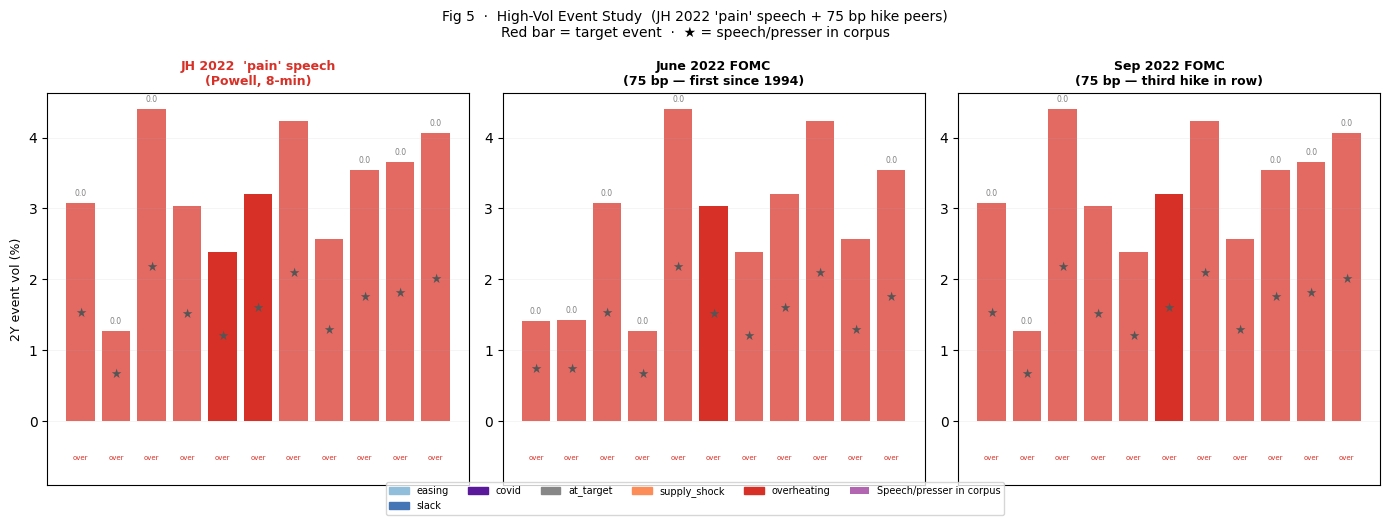

In [14]:
def fig5_event_study() -> None:
    df_p = model_panel.dropna(subset=["rv_gk_2Y"]).sort_values("meeting_date")
    df_p["meeting_date"] = pd.to_datetime(df_p["meeting_date"])

    events = [
        ("2022-08-26", "JH 2022  'pain' speech\n(Powell, 8-min)",   True),
        ("2022-06-15", "June 2022 FOMC\n(75 bp — first since 1994)", False),
        ("2022-09-21", "Sep 2022 FOMC\n(75 bp — third hike in row)", False),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
    fig.suptitle(
        "Fig 5  ·  High-Vol Event Study  (JH 2022 'pain' speech + 75 bp hike peers)\n"
        "Red bar = target event  ·  ★ = speech/presser in corpus",
        fontsize=10)

    for ax, (ev_dt_str, ev_label, is_pain) in zip(axes, events):
        ev_dt = pd.Timestamp(ev_dt_str)
        idx   = df_p["meeting_date"].searchsorted(ev_dt)
        lo, hi = max(0, idx-5), min(len(df_p), idx+6)
        sub   = df_p.iloc[lo:hi]

        bar_cols = [REGIME_PALETTE.get(l, "#878787") for l in sub["regime_label"]]
        ax.bar(range(len(sub)), sub["rv_gk_2Y"], color=bar_cols, alpha=0.72)

        # Highlight target event
        for i, (_, row) in enumerate(sub.iterrows()):
            if abs((row["meeting_date"] - ev_dt).days) < 35:
                ax.bar(i, row["rv_gk_2Y"], color="#d73027", alpha=1.0, zorder=3)

        # Text score above bar
        for i, (_, row) in enumerate(sub.iterrows()):
            uc = float(row.get("uncertainty_density", 0) or 0)
            if uc > 0:
                ax.text(i, row["rv_gk_2Y"] + 0.1, f"{uc:.1f}",
                        fontsize=5.5, ha="center", color="grey")

        # Star for presser/speech
        for i, (_, row) in enumerate(sub.iterrows()):
            match = corpus_df[(corpus_df["meeting_date"] == row["meeting_date"]) &
                              (corpus_df["doc_type"].isin(["speech","presser"]))]
            if not match.empty:
                mc = "purple" if (match["doc_type"] == "speech").any() else "#555555"
                ax.text(i, row["rv_gk_2Y"] * 0.48, "★",
                        fontsize=9, ha="center", color=mc)

        # Regime stripe at bottom
        for i, (_, row) in enumerate(sub.iterrows()):
            ax.text(i, -0.55, str(row["regime_label"])[:4], fontsize=5,
                    ha="center", color=REGIME_PALETTE.get(row["regime_label"], "grey"))

        ax.set_title(ev_label, fontsize=9,
                     color="#d73027" if is_pain else "black", fontweight="bold")
        ax.set_xticks([])
        ax.set_ylabel("2Y event vol (%)" if ax is axes[0] else "", fontsize=9)
        ax.set_ylim(bottom=-0.9)
        ax.grid(True, axis="y", alpha=0.18, lw=0.5)

    star_h = mpatches.Patch(facecolor="purple", alpha=0.6, label="Speech/presser in corpus")
    fig.legend(handles=_regime_handles + [star_h], fontsize=7,
               loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout()
    _save(fig, "fig5_event_study")


fig5_event_study()

---
## Cell 14 — Fig 6: Doc-Type Ablation

Walk-forward OOS sign-hit rate as the corpus expands from
statements only → + press conferences → + Jackson Hole speeches.

**Honest reporting:** if bars do **not** rise, we report that.
Adding text is only valuable if it adds OOS signal — not just if it
feels richer.

  Statements only                SHR=68.6%  n=51
  + Press conferences            SHR=68.6%  n=51
  + Jackson Hole speeches        SHR=68.6%  n=51


  Saved → figures/fig6_ablation.png


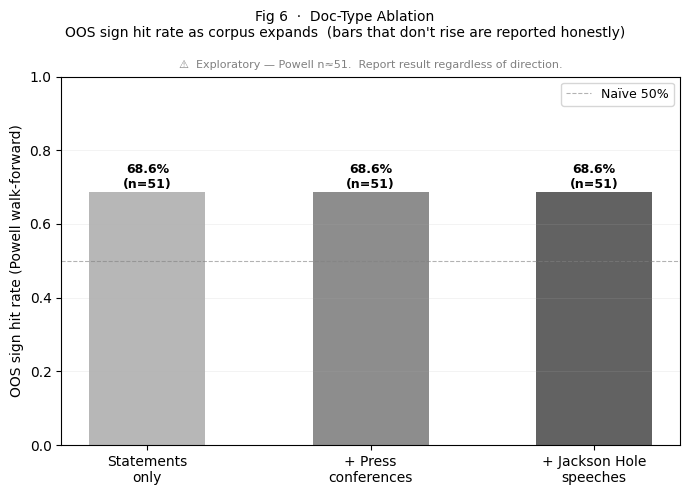

In [15]:
def fig6_ablation() -> None:
    target  = "rv_gk_2Y"
    subs_pw = model_panel[model_panel["meeting_date"] >= POWELL_START].dropna(
        subset=[target]).sort_values("meeting_date").reset_index(drop=True)
    meetings = sorted(subs_pw["meeting_date"].unique())

    def _oos_shr(zero_out_feats: set[str]) -> tuple[float, int]:
        hits = []
        sub  = subs_pw.copy()
        for f in zero_out_feats:
            if f in sub.columns:
                sub[f] = 0.0
        for i, dt in enumerate(meetings):
            if i < MIN_TRAIN: continue
            tr = sub[sub["meeting_date"] < dt].dropna(subset=TEXT_FEATURES[:2] + [target])
            te = sub[sub["meeting_date"] == dt]
            if len(tr) < 8 or te.empty: continue
            cols = [c for c in TEXT_FEATURES if c in tr.columns]
            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(tr[cols].fillna(0).values)
            X_te   = scaler.transform(te[cols].fillna(0).values)
            try:
                pred = RidgeCV(alphas=ALPHA_RANGE).fit(X_tr, tr[target].values).predict(X_te)[0]
                hits.append(int(np.sign(pred - tr[target].mean()) ==
                                np.sign(te[target].iloc[0] - tr[target].mean())))
            except Exception:
                continue
        return (float(np.mean(hits)) if hits else np.nan, len(hits))

    configs = [
        ("Statements\nonly",          {"uncertainty_density_presser","disagree_density_presser",
                                       "guidance_specificity_presser"}),
        ("+ Press\nconferences",      {"guidance_specificity_speech","uncertainty_density_speech"}),
        ("+ Jackson Hole\nspeeches",  set()),
    ]

    rates, ns = [], []
    for lbl, zeroed in configs:
        r, n = _oos_shr(zeroed)
        rates.append(r); ns.append(n)
        print(f"  {lbl.replace(chr(10),' '):<30} SHR={r:.1%}  n={n}")

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(
        "Fig 6  ·  Doc-Type Ablation\n"
        "OOS sign hit rate as corpus expands  "
        "(bars that don't rise are reported honestly)",
        fontsize=10)

    labels = [l for l, _ in configs]
    bars   = ax.bar(labels, rates, color=["#aaaaaa","#777777","#444444"],
                    alpha=0.84, width=0.52)
    ax.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.6, label="Naïve 50%")
    for b, r, n in zip(bars, rates, ns):
        if not np.isnan(r):
            ax.text(b.get_x() + b.get_width()/2, r + 0.012, f"{r:.1%}\n(n={n})",
                    ha="center", fontsize=9, fontweight="bold")

    ax.set_ylim(0, 1)
    ax.set_ylabel("OOS sign hit rate (Powell walk-forward)", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.2, lw=0.5)
    ax.set_title(
        f"⚠  Exploratory — Powell n≈{ns[-1]}.  Report result regardless of direction.",
        fontsize=8, color="grey")
    fig.tight_layout()
    _save(fig, "fig6_ablation")


fig6_ablation()

---
## Cell 15 — Caveats & Output Summary

**Five caveats to carry into any presentation:**

1. **Regime conditioning can overfit.** Validated OOS on Powell (Fig 4).
   If the acceptance test returns `FLAG`, do **not** claim the mechanism.

2. **Press-conference / speech normalisation.** Scores are densities per 1k tokens —
   not raw counts.  Do not compare raw scores across `doc_type`.

3. **Dual-mandate regime is economically primitive.** UNRATE / PCEPILFE / NROU
   are defined by BLS/BEA/FOMC — never from vol outcomes.  Thresholds
   are Taylor-rule intuition, not vol-calibrated.

4. **Powell is the backtest; Warsh is the forward test.**  Warsh CI is very wide (n=1+).

5. **Small sample.** Powell ≈ 55 meetings; OOS ≈ 40.  Bootstrap CIs are wide.
   Per-regime cells may have n < 10.

In [16]:
print("═" * 62)
print("  OUTPUT SUMMARY")
print("═" * 62)
print(f"  Corpus   : {CORPUS_OUT}")
print(f"  Regime   : {REGIME_OUT}")
print(f"  Forecasts: {MODEL_OUT}")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  Figure   : {f}")
print(f"  Loading matrix: {FIG_DIR/'fig3_loading_matrix.csv'}")
print("═" * 62)
print()
print(f"  Acceptance-test verdict : {verdict}")
print()
print("  CAVEATS")
print("  1. If acceptance test = FLAG, do not claim the mechanism.")
print("  2. Score densities per 1k tokens — not raw counts.")
print("  3. Dual-mandate regime never derived from vol outcomes.")
print("  4. Warsh is forward test (n=1+), NOT validation.")
print("  5. Small sample — all results are exploratory.")

══════════════════════════════════════════════════════════════
  OUTPUT SUMMARY
══════════════════════════════════════════════════════════════
  Corpus   : fomc_corpus_expanded.parquet
  Regime   : fomc_dual_mandate_regime.parquet
  Forecasts: fomc_nlp_regime_forecasts.parquet
  Figure   : figures/diag_d1_stage1.png
  Figure   : figures/diag_d2_spec_comparison.png
  Figure   : figures/diag_d4_full_history.png
  Figure   : figures/diag_d5_warsh.png
  Figure   : figures/fig1_phase_map.png
  Figure   : figures/fig2_regime_timeline.png
  Figure   : figures/fig3_loading_heatmap.png
  Figure   : figures/fig4_oos_scatter.png
  Figure   : figures/fig5_event_study.png
  Figure   : figures/fig6_ablation.png
  Figure   : figures/vrp_v1_regime_distribution.png
  Figure   : figures/vrp_v2_timeseries.png
  Figure   : figures/vrp_v3_calibration.png
  Figure   : figures/vrp_v4_nlp_iv_alignment.png
  Figure   : figures/vrp_v5_warsh.png
  Figure   : figures/vrp_v6_four_series.png
  Figure   : figures/vr